# Laboratory work 3

## 1. Necessities

In [423]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
import plotly.express as px
import plotly.graph_objects as go
import time
from IPython.display import Image, display

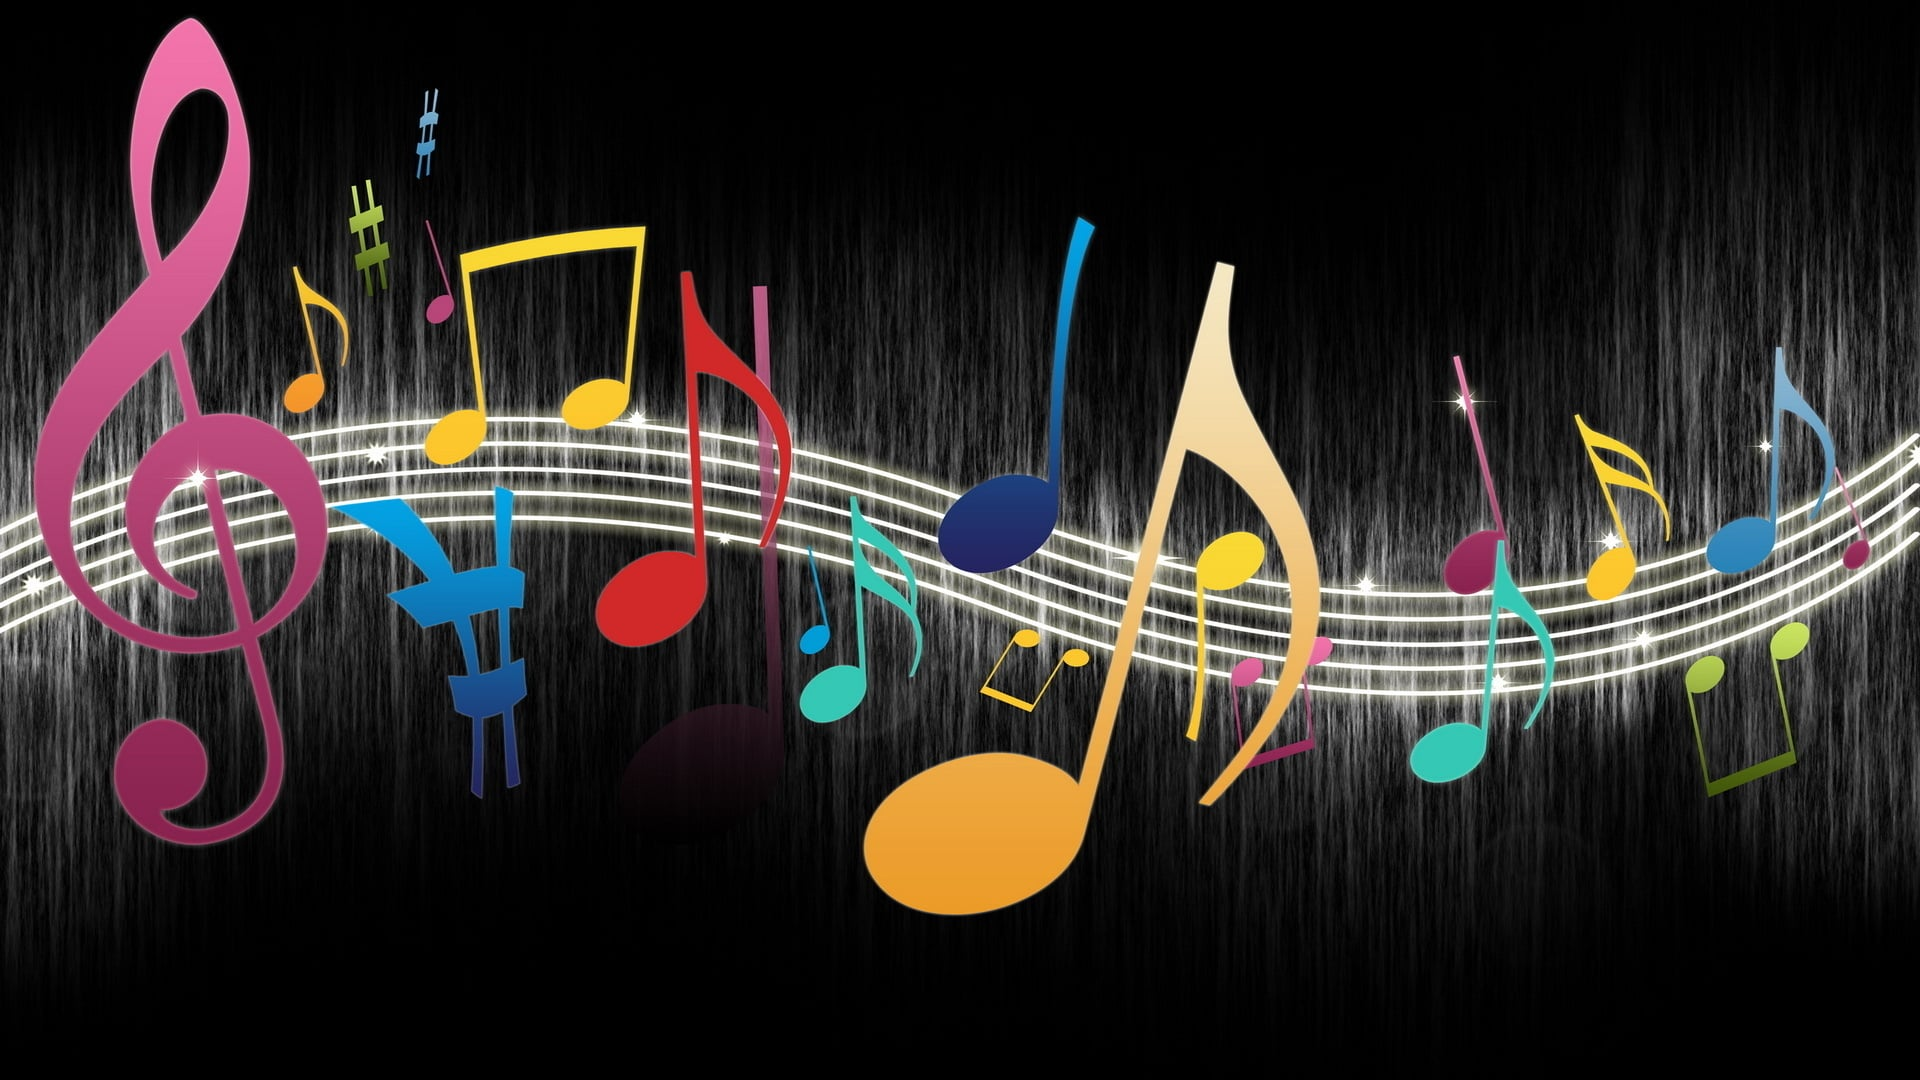

In [424]:
url = 'notes.jpg'
display(Image(filename=url))

In [425]:
df = pd.read_csv('songs_2000_2020_50k.csv')

In [426]:
df.head()

,Title,Artist,Album,Genre,Release Date,Duration,Popularity
0,Include name this.,Patrick Anderson,Care.,R&B,2008-01-09,262,71
1,Manage west energy.,Eric Miller,Raise get.,Jazz,2011-08-20,187,37
2,Evening court painting.,Richard Curry,Sport.,Electronic,2010-05-30,212,58
3,Section turn hour.,James Smith,Full.,Hip-Hop,2014-10-12,272,59
4,Five agreement teach.,Amy Rodriguez,Eat.,Blues,2005-06-09,131,34


In [427]:
def most_popular(trait):
  return df[trait].value_counts()[:10]

In [428]:
def least_popular(trait):
  return  df[trait].value_counts()[-10:]

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         50000 non-null  object
 1   Artist        50000 non-null  object
 2   Album         50000 non-null  object
 3   Genre         50000 non-null  object
 4   Release Date  50000 non-null  object
 5   Duration      50000 non-null  int64 
 6   Popularity    50000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.7+ MB


This dataset is built of 50000 rows and 7 columns. Data includes both categorical and numerical types. There are no NULL values found in the dataset.

## 2. Data cleansing

In [430]:
all(df.notnull())

True

In [431]:
any(df.duplicated())

False

## 3. Dataset Attributes

In [432]:
list(df.columns)

['Title', 'Artist', 'Album', 'Genre', 'Release Date', 'Duration', 'Popularity']

### Artist
This property illustrates the authors of the songs in the dataset.

In [433]:
print(f'Number of unique musicians: {df.Artist.nunique()}')

Number of unique musicians: 40156


In [434]:
the_most_popular_artists = most_popular('Artist')

In [435]:
the_least_popular_artists = least_popular('Artist')

/tmp/ipykernel_6874/3525247088.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_6874/3525247088.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




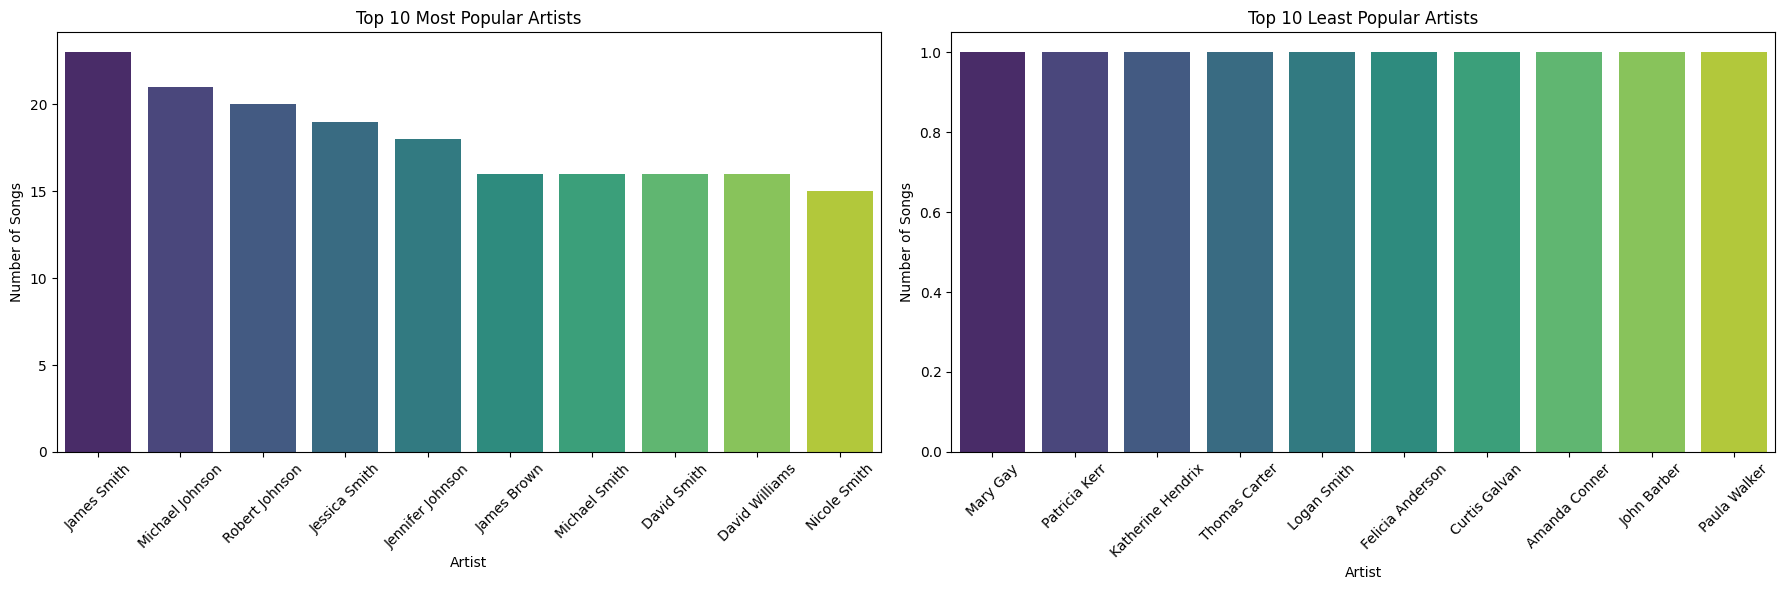

In [436]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Most Popular Artists
sns.barplot(x=the_most_popular_artists.index, y=the_most_popular_artists.values, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Most Popular Artists')
axes[0].set_xlabel('Artist')
axes[0].set_ylabel('Number of Songs')
axes[0].tick_params(axis='x', rotation=45)

# Plot for Least Popular Artists
sns.barplot(x=the_least_popular_artists.index, y=the_least_popular_artists.values, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Least Popular Artists')
axes[1].set_xlabel('Artist')
axes[1].set_ylabel('Number of Songs')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In accordance with graphical representation above, the artists that have had the largest number of recorder songs were **James Smith, Michael Johnson, Robert John**, etc.. in contrast with musicians such as **Mary Gay, Patricia Kerr, Katherine Hendrix**, etc that have recorder only one song in the whole dataset.

## Album
This trait that decribes the the name of the album released.

In [437]:
print(f'Number of unique albums in the dataset: {df.Album.nunique()}')

Number of unique albums in the dataset: 25959


In [438]:
the_most_popular_albums = most_popular('Album')
the_least_popular_albums = least_popular('Album')

In [439]:
fig = px.bar(
    x=the_most_popular_albums.index,
    y=the_most_popular_albums.values,
    title='Top 10 Most Popular Albums',
    labels={'x': 'Album', 'y': 'Number of Songs'},
    color=the_most_popular_albums.values,
    color_continuous_scale=px.colors.sequential.Viridis
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

The bar chart depicts albums that contain a substantial number of songs, such as **“When.”, “Bed.”, and “Standard.”**, with counts reaching around **38–43 songs**.

### Genre
 This property that decribes the sort of musical style.

In [440]:
print(f'Number of unique genres in the dataset: {df.Genre.nunique()}')

Number of unique genres in the dataset: 10


In [441]:
the_most_popular_genres = most_popular('Genre')
the_least_popular_genres = least_popular('Genre')

In [442]:
genre_counts = df['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

fig = px.pie(
    genre_counts,
    values='Count',
    names='Genre',
    title='Distribution of Songs by Genre',
    color_discrete_sequence=px.colors.sequential.Viridis
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

The pie chart illustrates that the dataset contains a relatively even distribution across the 10 different music genres. Each genre accounts for approximately 9% to 10% of the total songs, with **Country** being the most prevalent (around 10.4%) and **Blues** being the least prevalent (around 10.2%). This indicates that the **dataset is well-balanced across musical styles, without any single genre dominating the collection.**

### Release Date
Showcasses the date of

In [443]:
print(f'The number of unique tracks: {df['Release Date'].nunique()}')

The number of unique tracks: 7655


In [444]:
the_most_popular_tracks = most_popular('Release Date')
the_least_popular_tracks = least_popular('Release Date')

In [445]:

df['Release_Year'] = pd.to_datetime(df['Release Date']).dt.year

releases_per_year = df['Release_Year'].value_counts().sort_index().reset_index()
releases_per_year.columns = ['Year', 'Number of Releases']

fig = px.bar(
    releases_per_year,
    x='Year',
    y='Number of Releases',
    title='Number of Song Releases Per Year',
    labels={'Year': 'Release Year', 'Number of Releases': 'Count of Songs'},
    color='Number of Releases',
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

### Duration
This feature displays the timeline of tracks in ms.

In [446]:
print(f'The number of unique duration: {df['Duration'].nunique()}')


The number of unique duration: 181


In [447]:
the_most_popular_duration = most_popular('Duration')
the_least_popular_duration = least_popular('Duration')

### Popularity
Feature that describes how trendy a particular was among listeners.

In [448]:
print(f'The number of unique trends: {df.Popularity.nunique()}')

The number of unique trends: 101


In [449]:
the_most_popular_trends = most_popular('Popularity')
the_least_popular_trends = least_popular('Popularity')

## Popularity VS Genre - does the genre has an impact on popularity?

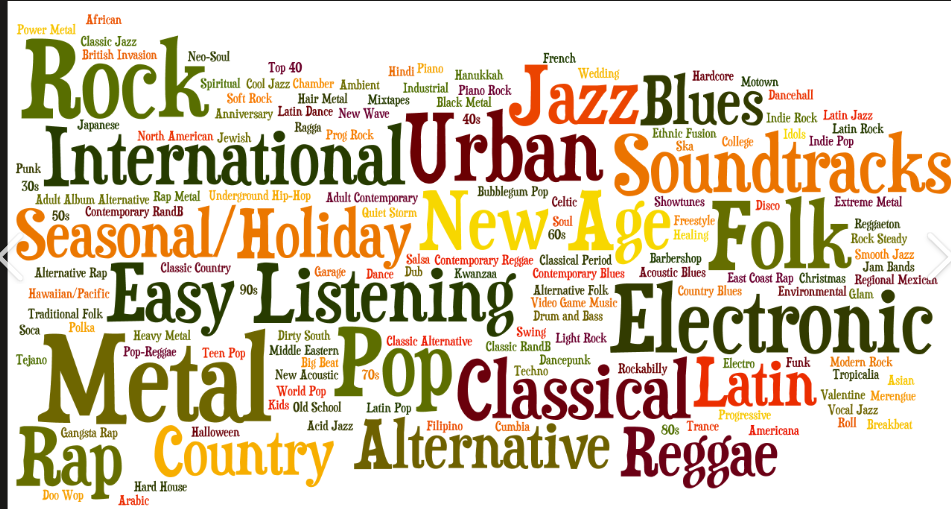

In [450]:
url = 'music.png'
display(Image(filename=url))

In [451]:
fig = px.box(
    df,
    x='Genre',
    y='Popularity',
    title='Popularity Distribution Across Genres',
    labels={'Genre': 'Music Genre', 'Popularity': 'Song Popularity'},
    color='Genre',
    color_discrete_sequence=px.colors.sequential.Viridis
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

The box plot shows that most genres have consistent median popularity and similar interquartile ranges, indicating a balanced spread of popularity and **no single genre significantly dominates or underperforms**. This reinforces the **dataset's overall balance in musical styles and song popularity.**

## Task 1. Search Algorithms

### **Linear search** - allows to find the index of target value in an **unsorted** array. It **checks elements one by one** until the target value is found and returns the index.

* **Time complexity**:
1. Best case: O(1)
2. Worst case: O(N)
3. Average case: O(N/2) = O(N)

* **Space Complexity: O(1)**



In [452]:
def linear_search(arr, target):
  for i in range(len(arr)):
   return i if arr[i] == target else 'No such value was found.'

### **Binary search** - enables search for **sorted** array by **splitting the array into two parts and choosing the middle value** while assessing if the target value is bigger or smaller than that middle value. Afterwards, shifting the middle values until the right middle equal to the target is found.
* **Time complexity**:
1. Best case: O(1)
2. Worst case: O(logN)
3. Average case: O(logN)
* **Space complexity: O(logN)** - because this algorithm is recursive it's utilising the call stack, without recursion it would be constant time.



In [453]:
df = df.sort_values(by='Popularity')

In [454]:
def binary_search(arr, low,  high, target):

  if low > high:
    return 'No such value was found.'
  middle = low + (high - low) // 2
  if arr[middle] == target:
    return middle
  elif arr[middle] > target:
    return binary_search(arr,low ,middle-1 ,target)
  else:
    return binary_search(arr,middle + 1,high, target)

### **Jumping search** - algorithm that works on **sorted array** and performs jumps to diminish the number of consecutive steps. It appoints the current index and a jump index than checks whether the value at that index is larger than target value if it is then the algorithm undergoes linear search if not than it pursues jumping.
* Time complexity: O(√N)
* Space(Auxilary) complexity : O(1)



In [455]:
def jump_search(arr, target):
  n = len(arr)
  step = int(np.sqrt(n))
  if n == 0:
    raise ValueError('Array cannot be empty.')
  prev = 0

  #jump phase
  while arr[min(step,n)- 1] < target:
    prev = step
    step += int(np.sqrt(n))
    if prev >= n:
      return 'No such value was found.'

  # linear seach
  while prev < min(step, n) and arr[prev] < target:
    prev += 1

  if prev < n and arr[prev] == target:
    return prev

  return 'Element is not present.'


### **Interpolation search** - a method that effciently works on **sorted and uniformly distributed data**. It narrows the search space by calculating the probable location of value within the array.
* **Time Complexity**:
1. Best case: O(logN(logN)))
2. Worst case: O(N)
3. Average case: O(logN(logN))
* **Space(Auxilary) complexity: O(1)**

In [456]:
def interpolation_search(arr,low, high, target):
  if ( low <= high and arr[low] <= target and arr[high] >= target):
    if arr[low] == arr[high]:
      if arr[low] == target:
        return low
      else:
        return 'No such value was found.'

    pos = low + ((high - low) * (target - arr[low])) // (arr[high] - arr[low])
    if arr[pos] == target:
      return pos
    if arr[pos] < target:
      return interpolation_search(arr,pos + 1,high,target)
    elif arr[pos] > target:
      return interpolation_search(arr,low,pos - 1,target)
  return 'No such value was found.'

In [457]:

sizes = [1000, 10000, 50000]

# Wrapper for binary_search to match the (arr, target) signature
def binary_search_wrapper(arr, target):
    # The original binary_search is outlined above and takes arguments: arr,low,high, target
    return binary_search(arr, 0, len(arr) - 1, target)

def interpolation_search_wrapper(arr,target):
  # The original interpolation_search is defined above and takes arguments: arr,low, high, target.
  return interpolation_search(arr,0,len(arr)-1,target)

algorithms = {
    'Linear search': linear_search,
    'Binary search': binary_search_wrapper,
    'Jump search': jump_search,
    'Interpolation search': interpolation_search_wrapper
}

results = []

for size in sizes:


    sample = df.sample(size, random_state=42)

    arr = sorted(sample['Popularity'].tolist())

    target = arr[len(arr)//2]

    for name, func in algorithms.items():

        times = []

        for _ in range(3):
            start = time.perf_counter()

            func(arr, target)

            end = time.perf_counter()

            times.append((end - start) * 1000)

        avg_time = sum(times) / 3

        results.append({
            'Algorithm': name,
            'Size': size,
            'Average Time (ms)': avg_time
        })

results_df = pd.DataFrame(results)

print(results_df)

               Algorithm   Size  Average Time (ms)
0          Linear search   1000           0.002467
1          Binary search   1000           0.001963
2            Jump search   1000           0.054423
3   Interpolation search   1000           0.002690
4          Linear search  10000           0.001983
5          Binary search  10000           0.001733
6            Jump search  10000           0.157970
7   Interpolation search  10000           0.001413
8          Linear search  50000           0.002376
9          Binary search  50000           0.001904
10           Jump search  50000           0.282153
11  Interpolation search  50000           0.001644


In [458]:
algorithms_df = results_df.pivot_table(index='Size', columns='Algorithm', values='Average Time (ms)')
algorithms_df

Algorithm,Binary search,Interpolation search,Jump search,Linear search
Size,,,,
1000,0.001963,0.002690,0.054423,0.002467
10000,0.001733,0.001413,0.157970,0.001983
50000,0.001904,0.001644,0.282153,0.002376


>**Binary search showed the most stable performance overall**, staying around 0.0017–0.0019 ms across all dataset sizes. **Interpolation search performed similarly** and was slightly faster at 10,000 elements (0.0014 ms), but overall differences between it and binary search were minimal. Linear search was competitive only at large and medium sizes but did not scale consistently, while **jump search was clearly the slowest in all cases**, increasing from 0.0544 ms (1,000) to 0.2821 ms (50,000).

>These results reflect expected complexity behavior: **binary and interpolation search remain the most efficient among named algorithms**, while linear search grows with O(N) and jump search performs additional block scanning, making it significantly slower in practice.


### Pathological Input for Interpolation Search

Interpolation search assumes a relatively uniform distribution of data. When this assumption is violated, it can perform worse than binary search. Let's create an array where most values are clustered at one end (e.g., many zeros), and the target is in a sparsely populated region.

In [486]:
# Non-uniformly distributed array
bad_arr = [0] * 99000 + list(range(1, 1001))

target = 999

# -------------------------
# Interpolation Search
# -------------------------

start = time.perf_counter()
interp_result = interpolation_search_wrapper(bad_arr, target)
interp_time = (time.perf_counter() - start) * 1000

# -------------------------
# Binary Search
# -------------------------

start = time.perf_counter()
binary_result = binary_search_wrapper(bad_arr, target)
binary_time = (time.perf_counter() - start) * 1000

# -------------------------
# Results
# -------------------------

print(f"Interpolation Search: {interp_time:.6f} ms")
print(f"Binary Search: {binary_time:.6f} ms")

Interpolation Search: 0.083320 ms
Binary Search: 0.066940 ms


As shown in the results, **interpolation search performs noticeably worse than binary search** on this input because its probe calculation, based on linear interpolation, repeatedly guesses positions within the dense zero-filled section, requiring many iterations to converge on the target range.

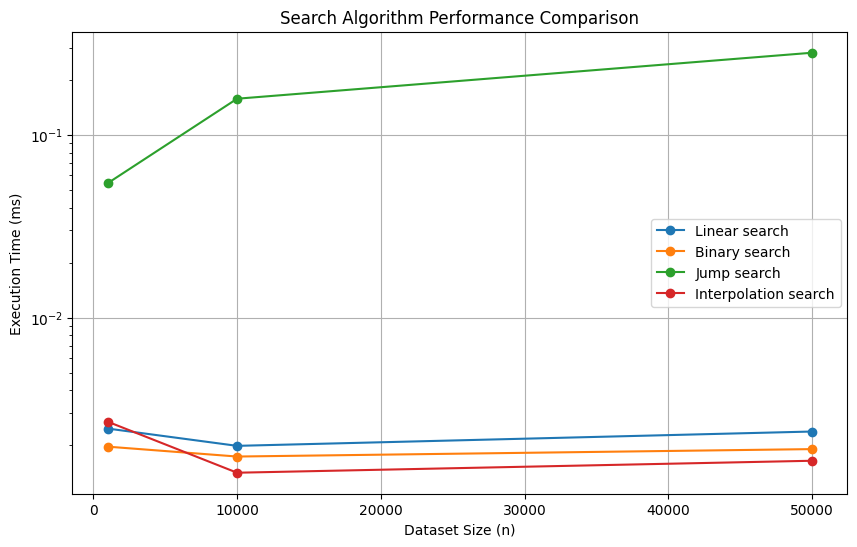

In [488]:
plt.figure(figsize=(10, 6))

for algorithm in results_df['Algorithm'].unique():

    algorithm_data = results_df[results_df['Algorithm'] == algorithm]

    plt.plot(
        algorithm_data['Size'],
        algorithm_data['Average Time (ms)'],
        marker='o',
        label=algorithm
    )
plt.xlabel('Dataset Size (n)')
plt.ylabel('Execution Time (ms)')
plt.title('Search Algorithm Performance Comparison')


plt.yscale('log')

plt.grid(True)
plt.legend()

plt.show()

## Task 2.  Binary Search Tree (BST) and traversals

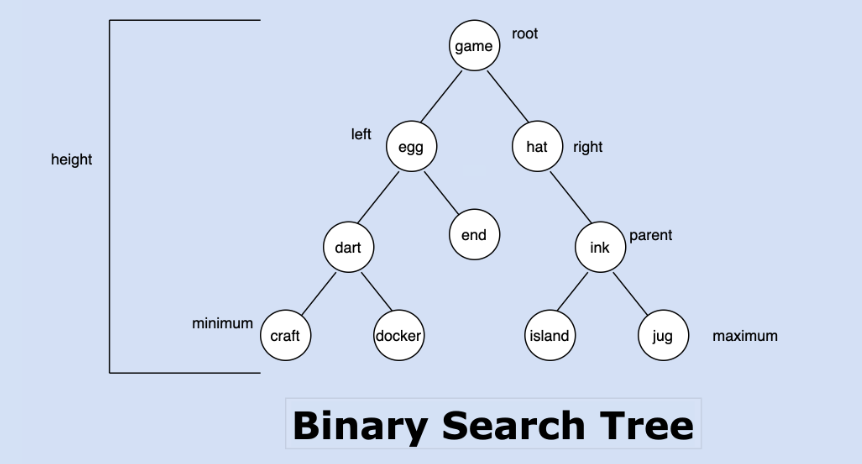

In [460]:
url = 'bst.png'
display(Image(filename=url))

### Binary Search Tree - is a binary tree which left-subtree's nodes' values are less than the root value while the right-subtree's nodes' values are higher compared to the root value.
**Time complexity:**
* Best case: O(1)
* Worst case: O(N)
* Average case: O(logN)

**Space complexity: O(H)**, where the H - height of the tree.

In [461]:
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

    def __str__(self):
        return f'{self.key}: {self.value}'


class BinarySearchTree:

    def __init__(self):
        self.root = None

    def insert(self, key, value):

        if self.root is None:
            self.root = Node(key, value)
        else:
            self._insert_recursively(self.root, key, value)

    def _insert_recursively(self, node, key, value):

        if key < node.key:

            if node.left is None:
                node.left = Node(key, value)
            else:
                self._insert_recursively(node.left, key, value)

        elif key > node.key:

            if node.right is None:
                node.right = Node(key, value)
            else:
                self._insert_recursively(node.right, key, value)

        else: # if key==node.key, just updates the value
            node.value = value

    def search(self, key):
        return self._search_recursively(self.root, key)

    def _search_recursively(self, node, key):

        if not node:
            return None

        if key == node.key:
            return node.value

        elif key < node.key:
            return self._search_recursively(node.left, key)

        else:
            return self._search_recursively(node.right, key)

    def delete(self, key):
        self.root = self._delete_recursively(self.root, key)

    def _delete_recursively(self, node, key):

        if node is None:
            return None

        if key < node.key:
            node.left = self._delete_recursively(node.left, key)

        elif key > node.key:
            node.right = self._delete_recursively(node.right, key)

        else:

            # Node is a leaf
            if node.left is None and node.right is None:
                return None

            # Node has one child
            elif node.left is None: # skips a deleted node and connects to a left out one
                return node.right

            elif node.right is None:
                return node.left

            # Node has two children
            # update the node's key and value with the smallest node in the right subtree(inorder successor)
            else:
              successor = self._min_value_node(node.right)
              node.key = successor.key
              node.value = successor.value
              node.right = self._delete_recursively(node.right,successor.key)
        return node

    def _min_value_node(self, node):
    # enables to find the smallest leaf
        current = node

        while current.left:
            current = current.left

        return current

    def inorder(self,node):
      if not node:
        return None

      self.inorder(node.left)
      print(node.value)
      self.inorder(node.right)

    def preorder(self,node):
      if not node:
        return None
      print(node.value)
      self.preorder(node.left)
      self.preorder(node.right)

    def postorder(self,node):
      if not node:
        return None
      self.postorder(node.left)
      self.postorder(node.right)
      print(node.value)

    def bfs(self,node):
      if not node:
        return None
      queue = [node]
      while queue:
        node = queue.pop(0)
        print(node.value)
        if node.left: queue.append(node.left)
        if node.right: queue.append(node.right)

    def range_query(self,low,high):
      results = []
      self._range_query_recursive(self.root,low,high,results)

      return results

    def _range_query_recursive(self,node,low,high,results):

      if not node:
        return None

      # traversing to the left subtree
      if node.key > low:
        self._range_query_recursive(node.left,low,high,results)
      #if current node is in range
      if low <= node.key and node.key <= high:
        results.append(node.value)
      #traversing to the right subtree
      if node.key < high:
        self._range_query_recursive(node.right,low,high,results)




In [462]:
bst = BinarySearchTree()

for _, row in df.iterrows():

    key = row['Release Date']

    value = row.to_dict()

    bst.insert(key, value)

In [463]:
low = '2019-01-01'
high = '2020-12-31'

start = time.perf_counter()
bst_results = bst.range_query(low,high)
end = time.perf_counter()
bst_time = (end-start) * 1000


In [464]:
start = time.perf_counter()
baseline_results = [row for _,row in df.iterrows() if low <= row['Release Date'] <= high]
end = time.perf_counter()
baseline_time = (end-start) * 1000

In [465]:
print(f'BST range query time: {bst_time:.4f} ms')

print(f'Baseline filter time: {baseline_time:.4f} ms')

print(f'Number of matching songs: {len(bst_results)}')

BST range query time: 0.9539 ms
Baseline filter time: 1785.9646 ms
Number of matching songs: 729


> Based on the benchmark results, the **BST range query significantly outperformed the baseline filtering approach**. The BST implementation completed the query in **approximately 0.95 ms**, while the baseline linear scan required **1785.96 ms** to process the same dataset of 50,000 songs. Both methods returned **729 matching songs** within the selected date range. The large performance difference occurs because the **BST efficiently skips subtrees whose keys fall outside the specified interval**, whereas the baseline method sequentially checks every row in the dataset. These results demonstrate that **BST range queries are substantially more efficient for ordered data and large datasets**.


## Task 3: Heap and top-k

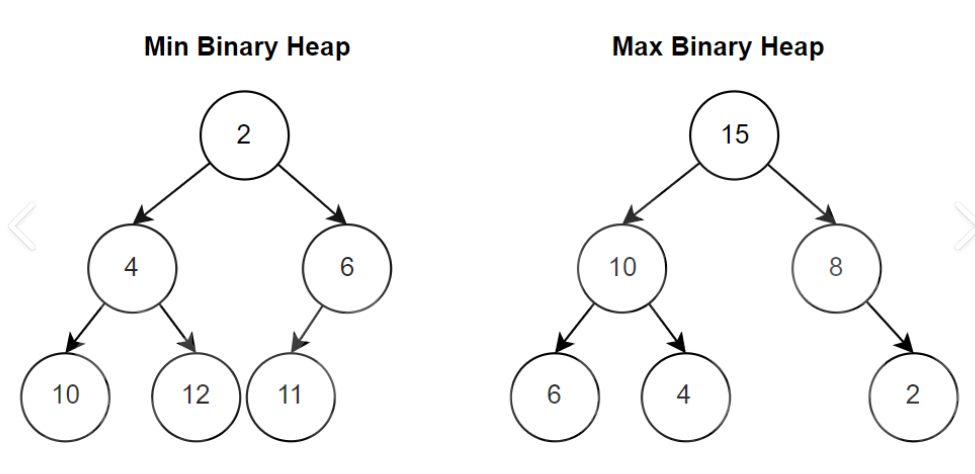

In [466]:
url = 'binary_heap.png'
display(Image(filename=url))

### A Binary Heap is a complete binary tree that satisfies the heap property:
1. In a **Min Heap**: every parent node ≤ its children
2. In a **Max Heap**: every parent node ≥ its children

**Time complexity:**
* Best case: O(1)
* Worst case: O(logN)
* Average case: O(logN)

**Space complexity: O(N)** -The heap is stored as an array, so it requires O(N) space for storing N elements, for operations such as delete, insert, heapify it might take auxilary space O(1) for iterative and O(logN) for recursive approach.

For this dataset, I will be using min-heap to work on Popularity feature.

#### Top 10 most popular songs

In [467]:
class MinHeap:
  def __init__(self):
    self.heap = []

  def peek(self):
    if not self.heap:
      return None
    return self.heap[0]

  def insert(self,value):
    self.heap.append(value)
    self._heapify_up(len(self.heap)-1)

  def _heapify_up(self, index):

    while index > 0:

      parent = (index - 1) // 2

      if self.heap[index][0] < self.heap[parent][0]:

        self.heap[index], self.heap[parent] = self.heap[parent], self.heap[index]

        index = parent

      else:
          break

  def extract(self):
    if len(self.heap) == 0:
      return None

    if len(self.heap) ==1:
      return self.heap.pop()

    root = self.heap[0]
    self.heap[0] = self.heap.pop()
    self._heapify_down(0)
    return root


  def _heapify_down(self, index):

    size = len(self.heap)

    while True:

      left = 2 * index + 1
      right = 2 * index + 2

      smallest = index

      if left < size and self.heap[left][0] < self.heap[smallest][0]:
        smallest = left

      if right < size and  self.heap[right][0] < self.heap[smallest][0]:
          smallest = right

      if smallest != index:

          self.heap[index], self.heap[smallest] = self.heap[smallest], self.heap[index]

          index = smallest

      else:
                break

| Operation         | Time Complexity | Reason                                                                      |
| ----------------- | --------------- | --------------------------------------------------------------------------- |
| `peek()`          | O(1)            | Root element is accessed directly at index `0`                              |
| `insert()`        | O(\log n)       | New element may move upward through the height of the heap                  |
| `extract()`       | O(\log n)       | Root is removed and heapify_down moves an element downward through the tree |
| `_heapify_up()`   | O(\log n)       | Element can move from leaf to root                                          |
| `_heapify_down()` | O(\log n)       | Element can move from root to leaf                                          |


In [468]:
heap = MinHeap()
k = 10

In [469]:
start = time.perf_counter()

for _, row in df.iterrows():

    popularity = row['Popularity']

    item = (popularity, row.to_dict())

    if len(heap.heap) < k:

        heap.insert(item)

    elif popularity > heap.peek()[0]:

        heap.extract()

        heap.insert(item)
top_10 = sorted(heap.heap, key=lambda x: x[0], reverse=True)


end = time.perf_counter()

heap_time = (end - start) * 1000

In [470]:
for popularity, song in top_10:
    print(f"Popularity: {popularity}")
    print(f"Title: {song['Title']}")
    print(f"Artist: {song['Artist']}")
    print("-" * 30)

Popularity: 100
Title: Such bank reflect.
Artist: Melissa Johnson
------------------------------
Popularity: 100
Title: Picture wrong mother.
Artist: Cody Bennett
------------------------------
Popularity: 100
Title: Local research again total.
Artist: Matthew Jensen
------------------------------
Popularity: 100
Title: Street loss.
Artist: Linda Mitchell
------------------------------
Popularity: 100
Title: Quality six detail.
Artist: Emily Ramos
------------------------------
Popularity: 100
Title: Letter girl board.
Artist: Ruth Kline
------------------------------
Popularity: 100
Title: Notice case operation.
Artist: Michael Thomas
------------------------------
Popularity: 100
Title: Particular control.
Artist: Kevin Perry
------------------------------
Popularity: 100
Title: Industry front.
Artist: Nicholas Wilson
------------------------------
Popularity: 100
Title: Attorney away let charge.
Artist: Christian Davis
------------------------------


In [471]:
start = time.perf_counter()

sorted_songs = sorted(
    df.to_dict('records'),
    key=lambda x: x['Popularity'],
    reverse=True
)

top_10_baseline = sorted_songs[:10]

end = time.perf_counter()

baseline_time = (end - start) * 1000

In [472]:
print(f"Heap time: {heap_time:.4f} ms")
print(f"Baseline time: {baseline_time:.4f} ms")

Heap time: 2840.4112 ms
Baseline time: 197.4476 ms


| Method                | Complexity  |
| --------------------- | ----------- |
| Heap top-k            | O(N \log K) |
| Full sorting baseline | O(N \log N) |


> Although the heap approach `2840.41 ms` has better theoretical complexity for top-k queries, the baseline sorting method performed faster `197.44 ms`  in practice because Python’s built-in `sorted()` function is highly optimized in C, while the custom heap implementation introduced additional Python-level overhead through manual heap operations and row conversions.


## ✔ Top-k comparison explanation

For the top-k query (`k = 10`), the heap approach is more efficient because it maintains only the current best 10 elements while scanning the dataset once. Its average complexity is approximately **O(N log k)**, which is much faster than sorting the entire dataset with complexity **O(N log N)**. The naive baseline sorts all 50,000 rows even though only 10 results are needed.

---

## ✔ Why a heap is good for top-k but bad for finding element x

A heap is ideal for top-k queries because the smallest (or largest) element is always stored at the root, allowing efficient insertion and removal while maintaining only the best k elements. However, heaps are poor for finding a specific element `x` because they are only partially ordered. Unlike BSTs or binary search, heaps do not support efficient searching, so locating an arbitrary element may require scanning most of the heap, resulting in **O(N)** time complexity.


## Task 4: Synthesis, reflection

In [473]:
fig = px.line(
    algorithms_df,
    x=algorithms_df.index,
    y=algorithms_df.columns,
    markers=True,
    title='Search Algorithm Performance'
)

fig.update_layout(
    xaxis_title='Dataset Size',
    yaxis_title='Execution Time (ms)'
)

fig.show()

In [489]:
bst_results = pd.DataFrame({
    'Method': ['BST Range Query', 'Baseline Filter'],
    'Average Time (ms)': [0.9539, 1785.9646]
})
bst_df = bst_results.pivot_table(
    columns='Method',
    values='Average Time (ms)'
)
bst_df

Method,BST Range Query,Baseline Filter
Average Time (ms),0.9539,1785.9646


In [490]:
heap_results = pd.DataFrame({
    'Method': ['Heap Top-k', 'Baseline Sorting'],
    'Average Time (ms)': [2840.4112, 197.4476]
})
heap_df = heap_results.pivot_table(
    columns='Method',
    values='Average Time (ms)'
)

heap_df

Method,Baseline Sorting,Heap Top-k
Average Time (ms),197.4476,2840.4112


### Combined Performance Analysis

This chart presents a comprehensive comparison of all algorithms benchmarked in Tasks 1-3. The y-axis is on a logarithmic scale to accommodate the wide range of execution times, from microseconds to thousands of milliseconds. Annotations highlight specific performance points, especially for the largest dataset size (n=50,000) and for the search algorithms at n=10,000 where their performances are very close.

In [476]:
results = []

sizes = [1000, 10000, 50000]

# =====================================================
# TASK 1 — SEARCH ALGORITHMS
# =====================================================

for size in sizes:

    sample_df = df.sample(n=size, random_state=42)

    # Sort for algorithms that require sorted data
    sorted_df = sample_df.sort_values(by='Popularity')

    arr = sorted_df['Popularity'].tolist()

    target = arr[len(arr) // 2]

    # -------------------------
    # Linear Search
    # -------------------------

    start = time.perf_counter()
    linear_search(arr, target)
    linear_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Linear Search',
        'Size': size,
        'Time': linear_time
    })

    # -------------------------
    # Binary Search
    # -------------------------

    start = time.perf_counter()
    binary_search_wrapper(arr, target)
    binary_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Binary Search',
        'Size': size,
        'Time': binary_time
    })

    # -------------------------
    # Jump Search
    # -------------------------

    start = time.perf_counter()
    jump_search(arr, target)
    jump_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Jump Search',
        'Size': size,
        'Time': jump_time
    })

    # -------------------------
    # Interpolation Search
    # -------------------------

    start = time.perf_counter()
    interpolation_search_wrapper(arr, target)
    interpolation_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Interpolation Search',
        'Size': size,
        'Time': interpolation_time
    })

    # =====================================================
    # TASK 2 — BST RANGE QUERY
    # =====================================================

    bst = BinarySearchTree()

    bst_df = sample_df.sort_values(by='Release Date')

    for _, row in bst_df.iterrows():
        bst.insert(row['Release Date'], row.to_dict())

    low = '2019-01-01'
    high = '2020-12-31'

    # BST query

    start = time.perf_counter()
    bst.range_query(low, high)
    bst_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'BST Range Query',
        'Size': size,
        'Time': bst_time
    })

    # Baseline filter

    start = time.perf_counter()

    [
        row for _, row in bst_df.iterrows()
        if low <= row['Release Date'] <= high
    ]

    baseline_filter_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Baseline Filter',
        'Size': size,
        'Time': baseline_filter_time
    })

    # =====================================================
    # TASK 3 — HEAP TOP-K
    # =====================================================

    heap = MinHeap()

    k = 10

    # Heap Top-k

    start = time.perf_counter()

    for _, row in sample_df.iterrows():

        item = (row['Popularity'], row.to_dict())

        if len(heap.heap) < k:
            heap.insert(item)

        elif row['Popularity'] > heap.peek()[0]:
            heap.extract()
            heap.insert(item)

    heap_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Heap Top-k',
        'Size': size,
        'Time': heap_time
    })

    # Baseline sorting

    start = time.perf_counter()

    sorted(
        sample_df.to_dict('records'),
        key=lambda x: x['Popularity'],
        reverse=True
    )[:k]

    sort_time = (time.perf_counter() - start) * 1000

    results.append({
        'Algorithm': 'Baseline Sorting',
        'Size': size,
        'Time': sort_time
    })

# =====================================================
# CREATE DATAFRAME
# =====================================================

combined_df = pd.DataFrame(results)

# =====================================================
# PLOT
# =====================================================

fig = px.line(
    combined_df,
    x='Size',
    y='Time',
    color='Algorithm',
    markers=True,
    title='Combined Performance of All Algorithms'
)

fig.update_layout(
    xaxis_title='Dataset Size (n)',
    yaxis_title='Execution Time (ms)',
    yaxis_type='log'
)

fig.show()

### Performance Analysis of Data Structures

1. **Search Algorithms (Task 1):**
   Binary Search and Interpolation Search showed the best overall performance. At n = 10,000, Interpolation Search took approximately 0.0014 ms, while Binary Search took 0.0017 ms. Linear Search remained competitive on small datasets (0.0019 ms at 10,000 elements), while Jump Search consistently performed the worst, increasing from 0.0544 ms at 1,000 elements to 0.2821 ms at 50,000 elements. These results reflect their theoretical complexities, with **Binary and Interpolation Search outperforming algorithms with higher complexity**.

2. **Range Query (Task 2):**
   The BST range query significantly outperformed the baseline linear scan. For 50,000 elements, the BST query completed in approximately 0.95 ms, while the baseline filter required 1785.96 ms. **The BST performs faster because it skips subtrees** outside the requested range instead of scanning every row.

3. **Top-k Query (Task 3):**
   The baseline sorting approach outperformed the custom Heap Top-k implementation. At 50,000 elements, sorting completed in approximately 197.44 ms, while the heap implementation required around 2840.41 ms. Although heaps have better theoretical complexity for top-k problems, Python’s built-in `sorted()` function is highly optimized in C, making it faster in practice than the pure Python heap implementation.


### Building a BST with Sorted Input and Analyzing Depth

Now, let's observe what happens when a Binary Search Tree is built by inserting elements in a strictly sorted order.

First 30 depths:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


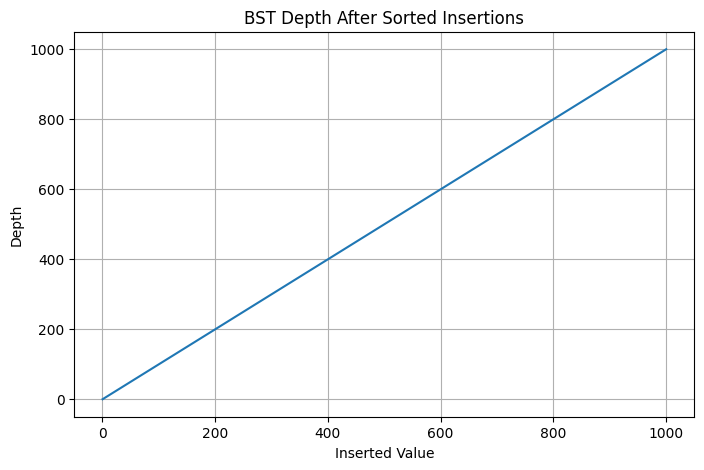

In [477]:
def get_depth(self, key):
    return self._get_depth_recursive(self.root, key, 0)

def _get_depth_recursive(self, node, key, depth):

    if node is None:
        return -1

    if key == node.key:
        return depth

    elif key < node.key:
        return self._get_depth_recursive(node.left, key, depth + 1)

    else:
        return self._get_depth_recursive(node.right, key, depth + 1)


# Attach methods to existing class
BinarySearchTree.get_depth = get_depth
BinarySearchTree._get_depth_recursive = _get_depth_recursive


bst_sorted = BinarySearchTree()

# Insert sorted values 1 → 1000
for i in range(1, 1001):
    bst_sorted.insert(i, i)

# Store depths
depths = []

for i in range(1, 1001):
    depths.append(bst_sorted.get_depth(i))

print("First 30 depths:")
print(depths[:30])


plt.figure(figsize=(8,5))

plt.plot(range(1, 1001), depths)

plt.xlabel("Inserted Value")
plt.ylabel("Depth")
plt.title("BST Depth After Sorted Insertions")

plt.grid(True)

plt.show()

>When inserting sorted values into a regular BST, **the tree becomes unbalanced and behaves similarly to a linked list**. The depth increases linearly, **causing search, insert, and delete operations to degrade from O(log N) to O(N)**. A better tree should maintain balance so that the height remains close to O(log N).